# Evolution of Topography and Sediment Transport Following Valley Glaciation #
### Ries Plescher, Katie Larkin, Mirna Kassem, Keya Hopwood ###

This notebook explores how recently deglaciated valleys evolve with bedrock landsliding and fluvial transport. 

First, let's get things imported:

In [1]:
# first lets get things imported
import numpy as np
import matplotlib.pyplot as plt
from landlab import RasterModelGrid
from landlab import imshow_grid, imshowhs_grid  # For plotting results
from landlab.components import BedrockLandslider  # BedrockLandslider model
from landlab.components import SpaceLargeScaleEroder  # SPACE model
from landlab.components import PriorityFloodFlowRouter
from landlab.components import FlowAccumulator
import copy

We define our initial conditions using a) theoretical u-shaped topography, and b) a real-life valley.

## a) Theoretical topography ##

Following Harbor (1992), ice flow flows in a valley according to a parabolic profile
$$z=ax^b$$
where $$b=2$$.

To establish a realistic channel long-profile, we add a seperate exponential expression in the y-direction using coefficients from Dadson and Church (2005), resulting in the general form
$$z=ax^b+cy^d$$
where $$c=85*10^{-3}$$ and $$d=1.75$$

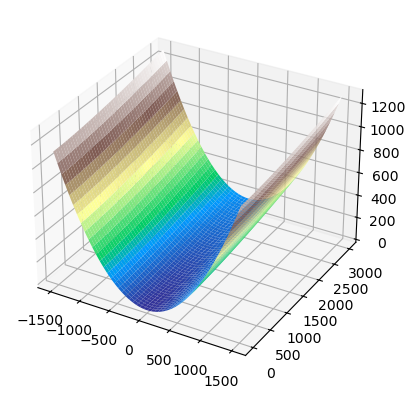

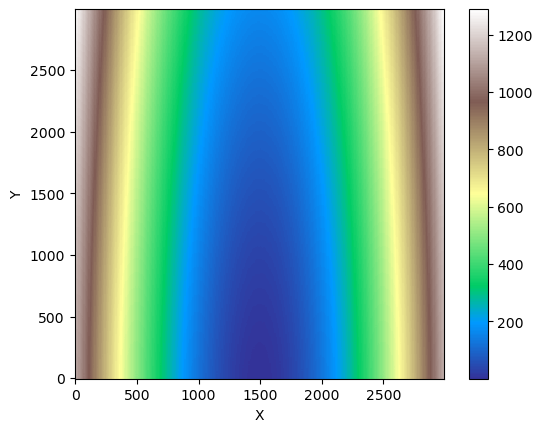

In [2]:
# set up a grid
grid_length = 3000.0 # meters
grid_width = 3000.0 # meters
grid_res = 10.0 # meters

xvals = np.linspace(-grid_width/2,grid_width/2,int(grid_width/grid_res))
yvals = np.linspace(0,grid_length,int(grid_length/grid_res))
xv, yv = np.meshgrid(xvals,yvals)

# parameters for parabolic glacial valley
a=0.0005 # set so that valley ridge height is realistic
b=2
c=1e-3
d=1.5
zv = a*(xv**b) + c*(yv**d)

# add a small amount of noise to reduce artifacting
noise = 0.5*np.random.rand(zv.shape[0],zv.shape[1])
sim_glac = zv + noise

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
surf = ax.plot_surface(xv,yv,sim_glac,cmap='terrain')

# # initialize a RasterGridObject
fig, ax = plt.subplots()
theo_grid = RasterModelGrid(sim_glac.shape, 10.0)
theo_grid.at_node["bedrock__elevation"] = sim_glac
theo_grid.imshow("bedrock__elevation",cmap='terrain')

## a) Real topography ##

We take this topography from somewhere in alaska idk

## b) Set boundary conditions ##

Let's establish some landscape characteristics for our theoretical or real topography (whichever you choose!)

In [3]:
# Can customize based on use.
grid = theo_grid
#grid = dem_grid

In [4]:
# Add a field 'soil__depth' to the grid, with a uniform depth of 1.
grid.add_ones("soil__depth", at="node", clobber=True)

# # Add field 'bedrock__elevation' to the grid
# grid.add_zeros("topographic__elevation", at="node", clobber=True)

# Sum 'soil__depth' and 'bedrock__elevation'
# to yield 'topographic elevation'
grid.at_node["topographic__elevation"] = grid.at_node["bedrock__elevation"] + grid.at_node["soil__depth"]
# grid.at_node["topographic__elevation"][:] += grid.at_node["soil__depth"]

In [5]:
#Set grid boundaries. 
#We are keeping one side of the grid open and closing the rest to best simulate our theoretical glacial valley.
grid.set_closed_boundaries_at_grid_edges(
    bottom_is_closed=False,
    left_is_closed=True,
    right_is_closed=True,
    top_is_closed=True,
)

In [6]:
# Instantiate flow router
fr = PriorityFloodFlowRouter(grid, surface='topographic__elevation', flow_metric="D8", suppress_out=True)

# Instantiate SPACE model with chosen parameters
sp = SpaceLargeScaleEroder(
    grid,
    K_sed=5e-5,
    K_br=1e-6,
    F_f=0.3,
    phi=0.35,
    H_star=0.5,
    v_s=1,
    m_sp=0.5,
    n_sp=1.0,
    sp_crit_sed=0,
    sp_crit_br=0,
)

/opt/tljh/user/envs/csdms/lib/python3.13/site-packages/richdem/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [7]:
# Set model timestep
timestep = 10  # years

# Set elapsed time to zero
elapsed_time = 0.0  # years

# Set timestep count to zero
count = 0

# Set model run time
run_time = 50 # years

# Array to save sediment flux values
sed_flux = np.zeros(int(run_time // timestep))

# Uplift rate in m/yr
U = 1e-2

cmap = copy.copy(plt.colormaps["terrain"])

while elapsed_time < run_time:  # time units of years
    # Insert uplift at core nodes
    grid.at_node["bedrock__elevation"][grid.core_nodes] += U * timestep
    grid.at_node["topographic__elevation"][:] = (
        grid.at_node["bedrock__elevation"] + grid.at_node["soil__depth"]
    )

    # Run the flow router
    fr.run_one_step()

    # Run SPACE for one time step
    sp.run_one_step(dt=timestep)

    # Add to value of elapsed time
    elapsed_time += timestep

    
    if np.mod(elapsed_time, 1e5) == 0:
        print("%.2f of model run completed" % (elapsed_time / run_time))
        imshow_grid(
            grid, "topographic__elevation", cmap=cmap, colorbar_label="Elevation (m)"
        )
        plt.show()

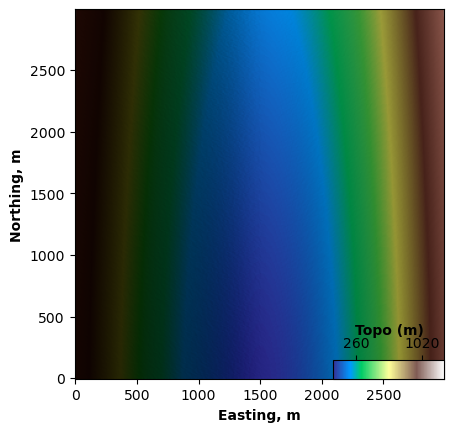

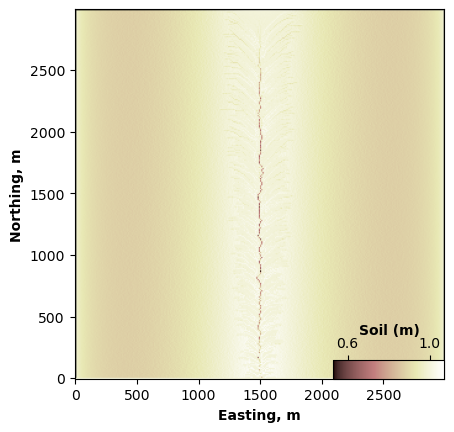

In [9]:
cmap = copy.copy(plt.colormaps["terrain"])
# Show DEM draped over the shaded topographic relief
imshowhs_grid(
    grid,
    "topographic__elevation",
    var_name="Topo",
    var_units=r"m",
    grid_units=("m", "m"),
    cmap=cmap,
    ticks_km=False,
)
plt.show()
# Show Soil thickness draped over the shaded topographic relief
cmap = copy.copy(plt.colormaps["pink"])
imshowhs_grid(
    grid,
    "topographic__elevation",
    drape1=grid.at_node["soil__depth"],
    plot_type="Drape1",
    var_name="Soil",
    var_units=r"m",
    grid_units=("m", "m"),
    cmap=cmap,
    ticks_km=False,
)

z_before_LS = np.array(grid["node"]["topographic__elevation"])

In [10]:
# Instantiate flow router, with additional multiple flow director for hillslopes
fr = PriorityFloodFlowRouter(
    grid,
    flow_metric="D8",
    separate_hill_flow=True,
    hill_flow_metric="Quinn",
    update_hill_flow_instantaneous=True,
)

# Instantiate Hylands model with chosen parameters
hy = BedrockLandslider(
    grid,
    angle_int_frict=0.7,
    cohesion_eff=1e6,
    landslides_return_time=1,
    landslides_on_boundary_nodes=False, 
)

[1126.22258921 1111.41533341 1096.57514343 ... 1260.88672474 1275.49772915
 1290.51580635]


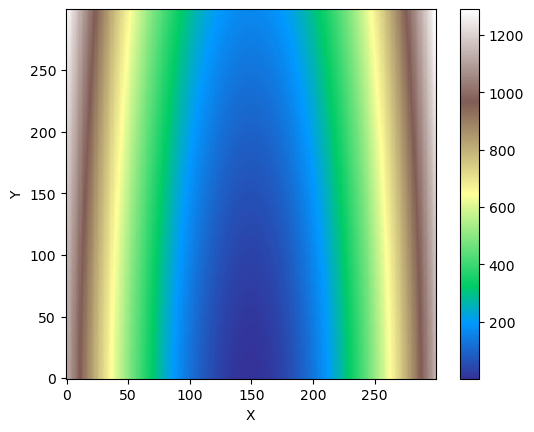

In [11]:
initial_top= grid.at_node['topographic__elevation']
print(initial_top)
new_grid = RasterModelGrid(grid.shape)
new_grid.at_node['topographic__elevation'] = initial_top
new_grid.imshow('topographic__elevation',cmap='terrain')


In [ ]:

new_grid = RasterModelGrid(grid.shape)
new_grid.at_node['topographic__elevation'] = all_topos[1]
new_grid.imshow['topographic__elevation']

all_topos = np.zeros(grid.shape[0], grid.shape[1], num_timesteps

all_topos[0] = grid.at_node['topographic__elevation']